In [79]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

(39209, 8)


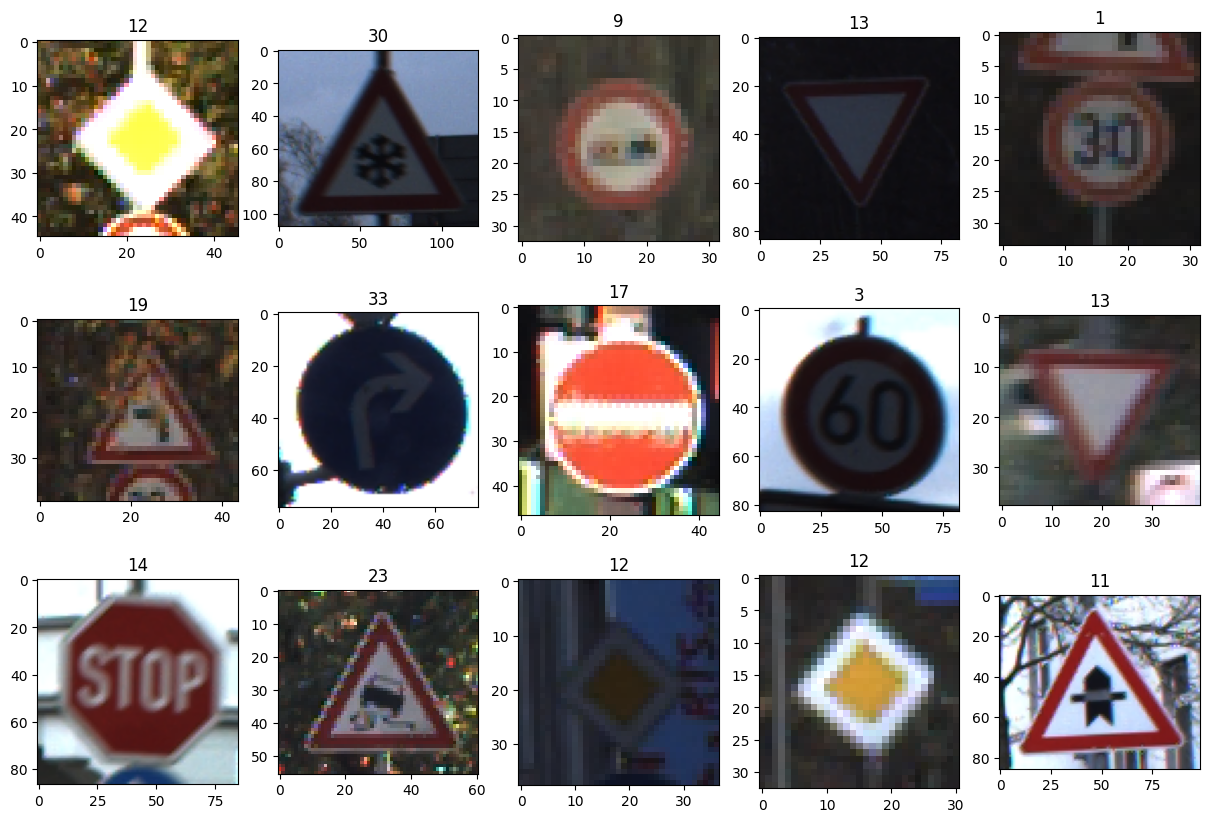

In [80]:
# Load the training labels
root = '/Users/iivaniv/computer_vision_data/archive/' # Path to the dataset location, e.g.
data = pd.read_csv(os.path.join(root, 'Train.csv'))

print(data.shape)

# Number of training samples (amount of samples in data)
num_samples = 39209

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId'])

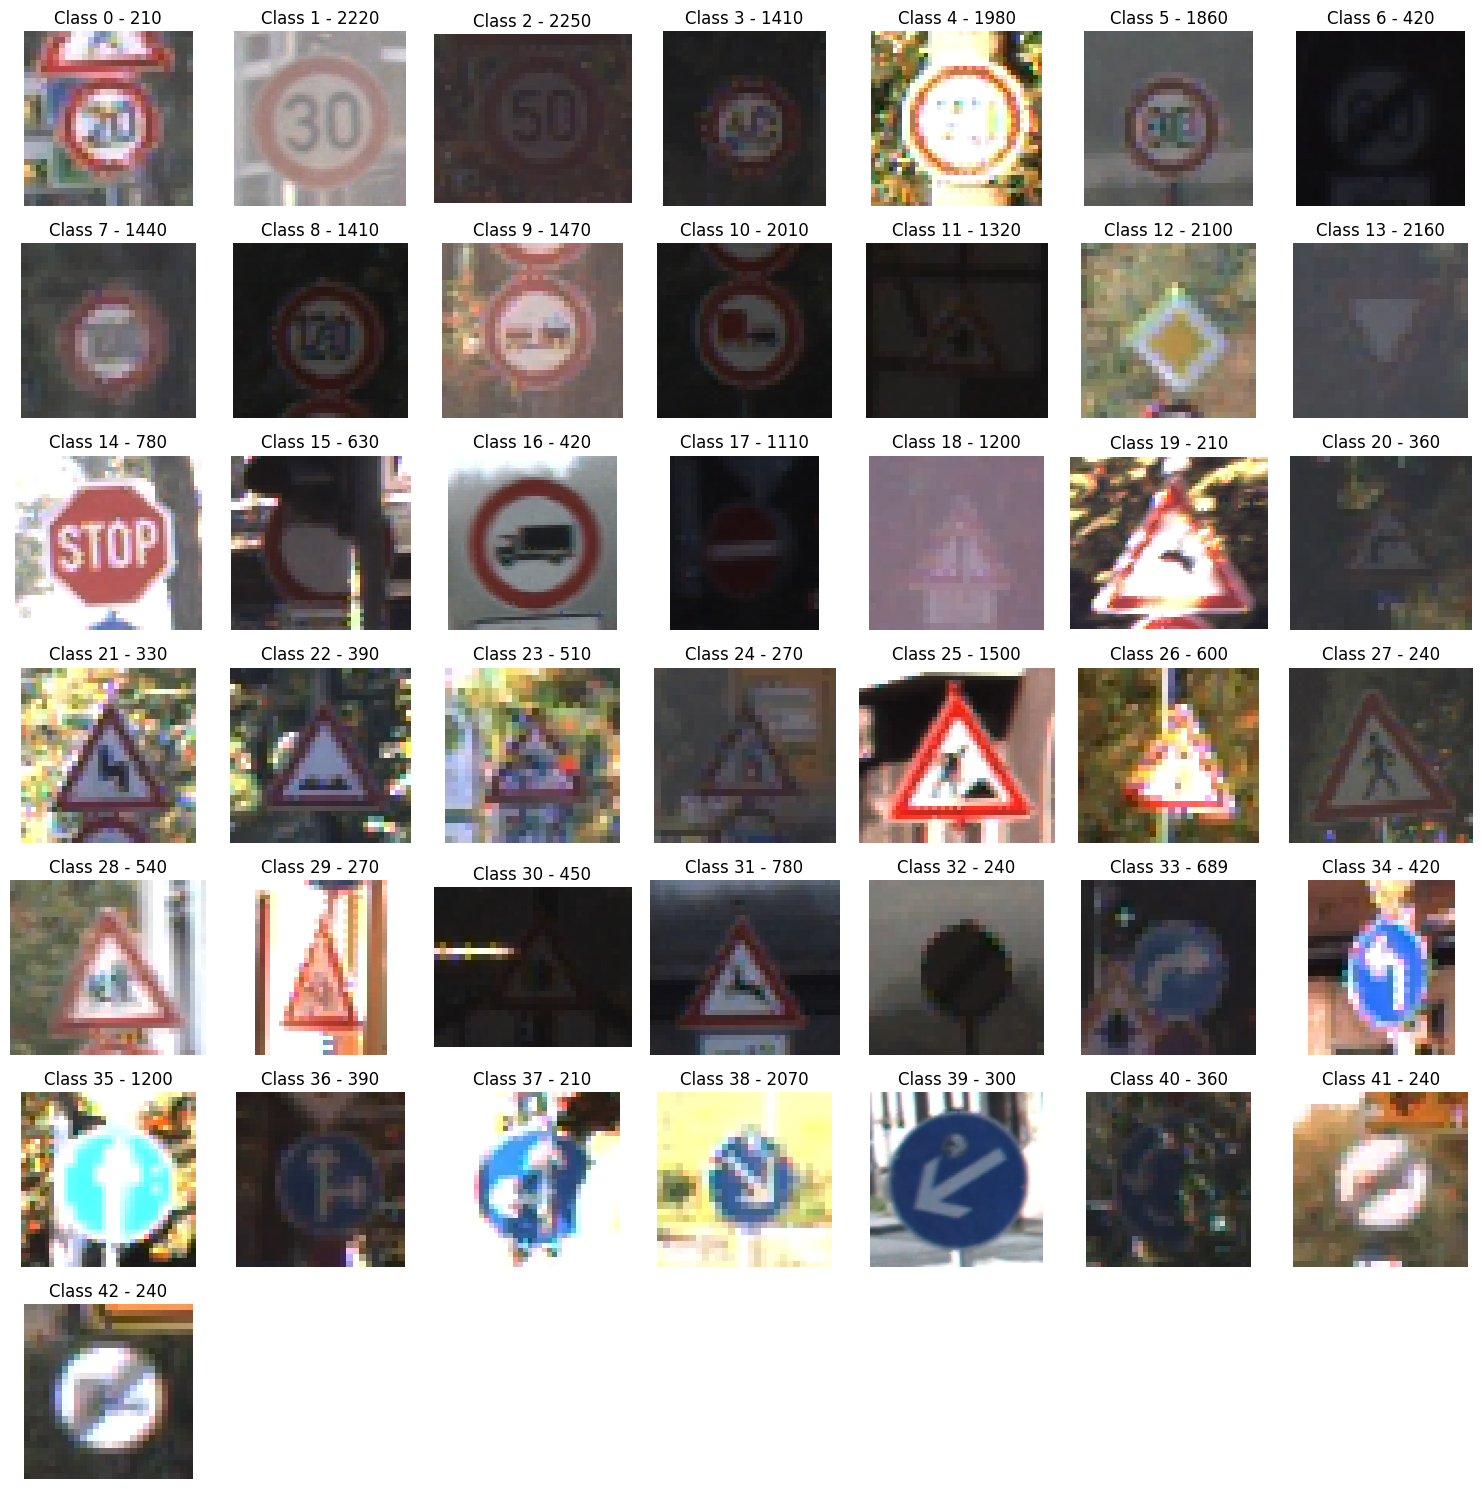

In [82]:
root = '/Users/iivaniv/computer_vision_data/archive/'  # Path to the dataset
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Create a figure
plt.figure(figsize=(15, 15))

# Iterate through all class IDs (0–42)
for class_id in range(43):
    # Get first sample of this class
    sample = data[data['ClassId'] == class_id].iloc[0]
    count = len(data[data['ClassId'] == class_id]);
    
    img_path = os.path.join(root, sample['Path'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # print("sample : ", sample)
    # print("img shape : ", img.shape)
    # Plot it
    plt.subplot(7, 7, class_id + 1)
    plt.imshow(img)
    plt.title(f"Class {class_id} - {count}")
    plt.axis('off')

plt.tight_layout()
plt.show()

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

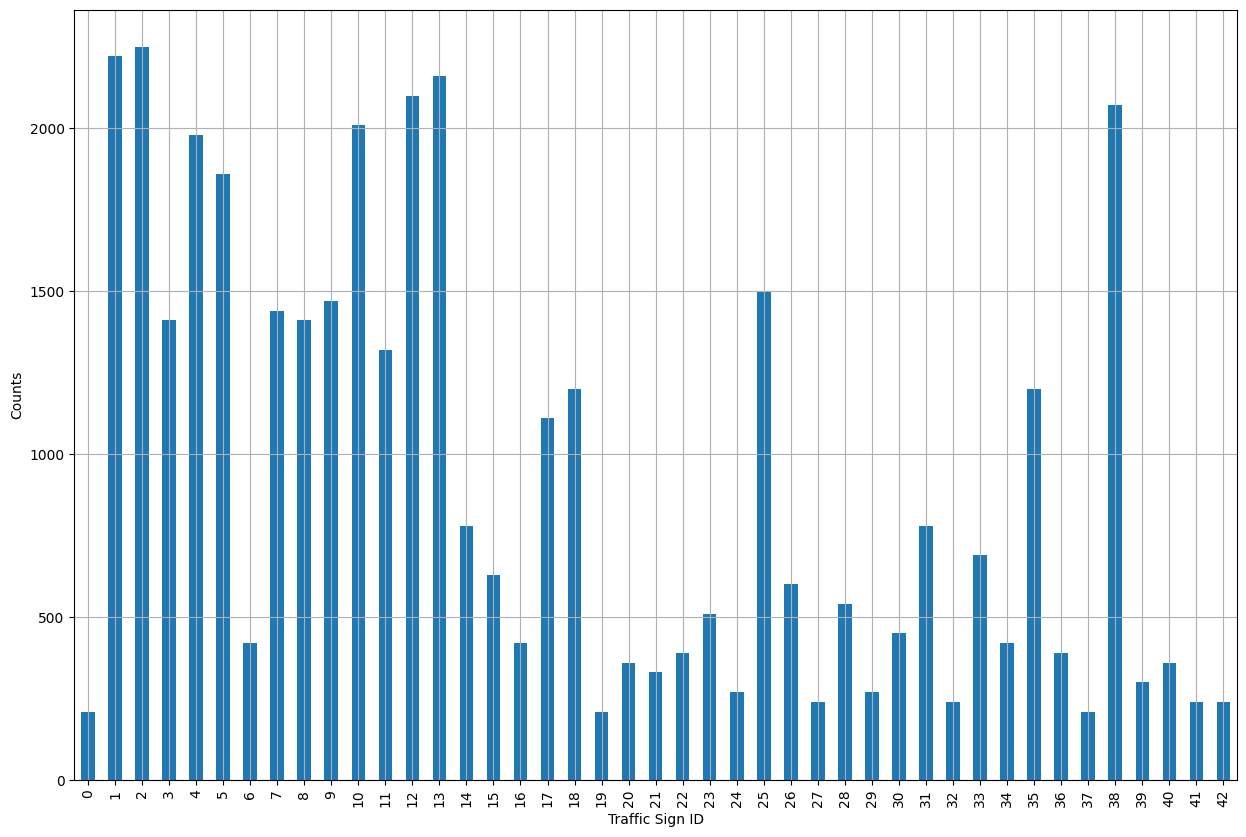

In [157]:
# Extract class identifiers
# Hint: Check the csv 
data = pd.read_csv(os.path.join(root, 'Train.csv'))
ids = data['ClassId']

hist = ids.value_counts().sort_index()

hist.plot(kind='bar'), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')


# Do you consider the dataset to be balanced? If so, why? If not, why?
    # A quick look shows that the dataset is not balanced. But I think some type of sign is not so common. This explains why the dataset contains relatively few images. 
    # Example: If we take a glance on sign Class_1 (20km/h speed restriction). 
    #          It’s a rare sign — you’re much more likely to see Class 2 (30 km/h restriction) or Class 3 (50 km/h restriction)
# Are there any classes that are (significantly) over-represented or under-represeneted?
    # I partialy answered this in the first question. But it could also depend on right-hand or left-hand traffic
    # I must also admit that there are many more examples of restriction signs than other types, which says a lot about Germany n  :)  

(2924, 2)
    Resolution  Count
30       31x31    396
159      30x30    380
55       35x35    360
236      32x32    352
54       33x33    351
..         ...    ...
240      49x49    133
260      43x44    129
474      45x46    125
389      44x43    125
28       29x31    125

[65 rows x 2 columns]


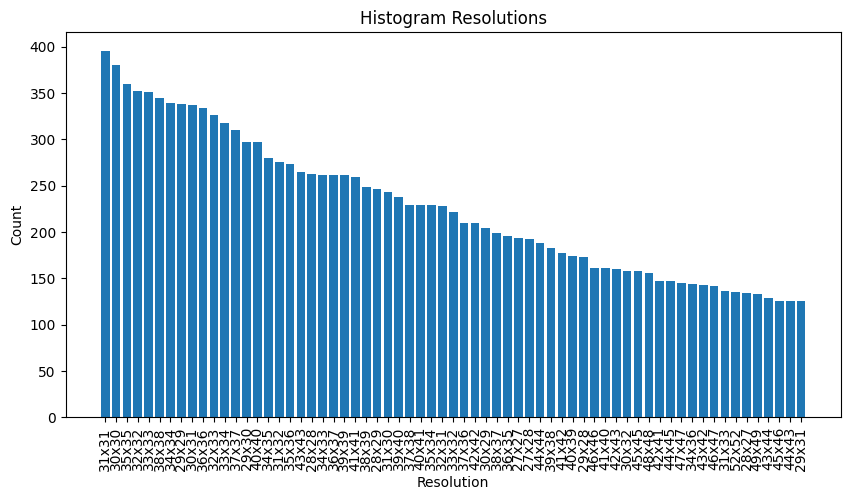

In [154]:
from collections import Counter

# 2. Group by Width, Height
resolutions = list(zip(data["Width"], data["Height"]))
counter = Counter(resolutions)

res_df = pd.DataFrame(counter.items(), columns=["Resolution", "Count"])
res_df["Resolution"] = res_df["Resolution"].apply(lambda x: f"{x[0]}x{x[1]}")
print(res_df.shape)

# show 65 most common resolution
res_df = res_df.sort_values("Count", ascending=False).head(65)
print(res_df)

plt.figure(figsize=(10, 5))
plt.bar(res_df["Resolution"], res_df["Count"])
plt.xticks(rotation=90)
plt.xlabel("Resolution")
plt.ylabel("Count")
plt.title("Histogram Resolutions")
plt.show()

# Most common resolutions 31x31, 30x30, etc. Relatively small images

In [172]:
def get_brightness(img_path):
    # Read image (in grayscale)
    img_path = os.path.join(root, img_path)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan  # skip missing images
    return img.mean()

data["Brightness"] = data["Path"].apply(get_brightness)
brightness_per_class = data.groupby("ClassId")["Brightness"].mean().reset_index()

counter_per_class = data["ClassId"].value_counts().reset_index()
counter_per_class.columns = ["ClassId", "Count"]
counter_per_class = counter_per_class.sort_values("ClassId")
print("counter_per_class ", counter_per_class)

counter_per_class      ClassId  Count
41        0    210
1         1   2220
0         2   2250
11        3   1410
6         4   1980
7         5   1860
26        6    420
10        7   1440
12        8   1410
9         9   1470
5        10   2010
13       11   1320
3        12   2100
2        13   2160
17       14    780
20       15    630
25       16    420
16       17   1110
14       18   1200
42       19    210
31       20    360
32       21    330
28       22    390
23       23    510
35       24    270
8        25   1500
21       26    600
37       27    240
22       28    540
34       29    270
24       30    450
18       31    780
36       32    240
19       33    689
27       34    420
15       35   1200
29       36    390
40       37    210
4        38   2070
33       39    300
30       40    360
38       41    240
39       42    240


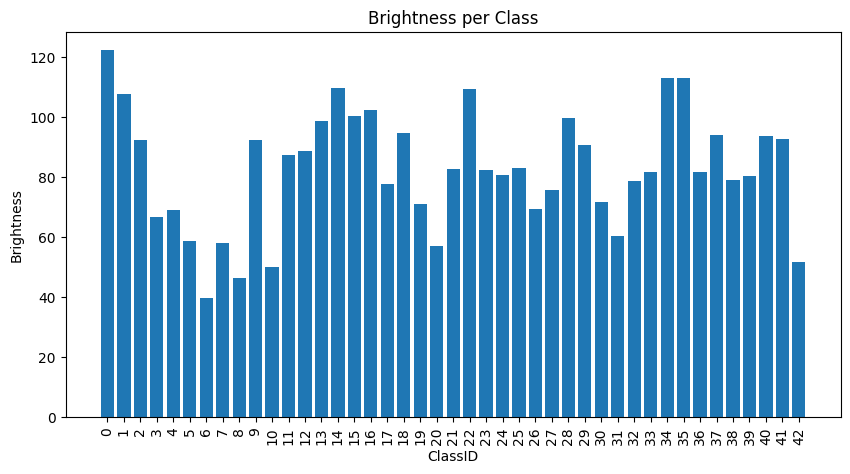

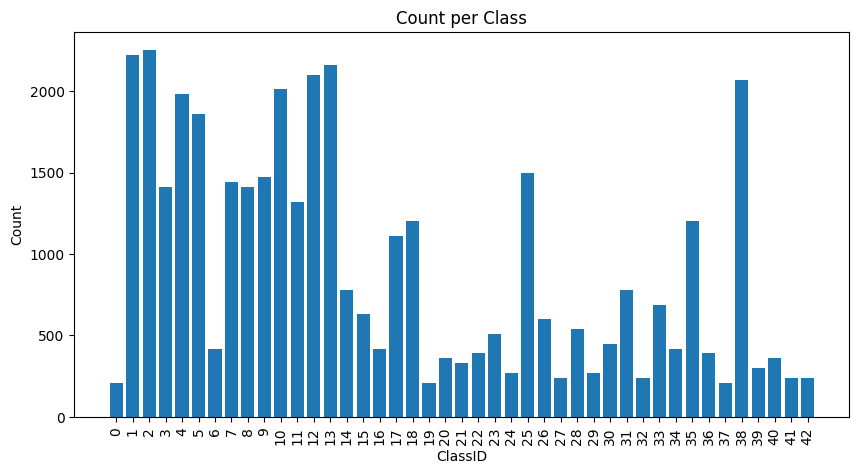

In [175]:
plt.figure(figsize=(10,5))
plt.bar(brightness_per_class["ClassId"].astype(str), brightness_per_class["Brightness"])
plt.xlabel("ClassID")
plt.xticks(rotation=90)
plt.ylabel("Brightness")
plt.title("Brightness per Class")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(counter_per_class["ClassId"].astype(str), counter_per_class["Count"])
plt.xlabel("ClassID")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Count per Class")
plt.show()


# probably we dont need a lot of examples for most brghness images 